In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [3]:
dataset.head(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0


Insure data has not null value

In [4]:
dataset.isnull().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0


In [5]:
input_data = dataset.iloc[:,:-1]
output_data = dataset["Exited"]

Scaling

In [6]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data),columns=input_data.columns)

Train Test Split data

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test = train_test_split(input_data,output_data,train_size=0.25,random_state=10)

In [9]:
x_train.shape

(2500, 8)

# ***MultiLayer Percepton***

In [10]:
import tensorflow

In [53]:
from keras.layers import Dense, BatchNormalization
from keras.regularizers import L2
from keras.callbacks import EarlyStopping

from keras.models import Sequential

In [54]:
ann = Sequential()

# *batch normalization*

In [55]:
ann.add(Dense(6,input_dim = 8,activation="relu",kernel_regularizer = L2(l2=0.01)))
ann.add(BatchNormalization())
ann.add(Dense(4,activation="relu"))
ann.add(BatchNormalization())
ann.add(Dense(2,activation="relu"))
ann.add(BatchNormalization())
ann.add(Dense(1,activation="sigmoid"))

In [56]:
ann.compile(optimizer = "adam", loss = "binary_crossentropy",metrics=['accuracy'])

In [57]:
ann.fit(x_train,y_train, batch_size=100, epochs = 50,validation_data=(x_test,y_test),callbacks=EarlyStopping())

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6436 - loss: 0.8003 - val_accuracy: 0.4065 - val_loss: 0.9047
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7020 - loss: 0.7618 - val_accuracy: 0.5271 - val_loss: 0.8402
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7312 - loss: 0.7367 - val_accuracy: 0.6056 - val_loss: 0.7918
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7492 - loss: 0.7072 - val_accuracy: 0.6560 - val_loss: 0.7515
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7568 - loss: 0.6890 - val_accuracy: 0.6883 - val_loss: 0.7200
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7648 - loss: 0.6673 - val_accuracy: 0.7115 - val_loss: 0.6951
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7708 - loss: 0.6482 - val_accuracy: 0.7361 - val_loss: 0.6697
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7776 - loss: 0.6304 - val_accuracy: 0.7559 - val_l

***Handling overfitting using Batch Normalization***

In [59]:
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

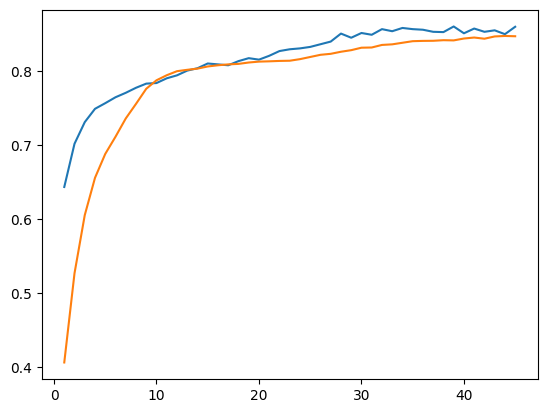

In [60]:
plt.plot([i for i in range(1,46)],train_accuracy)
plt.plot([i for i in range(1,46)],test_accuracy)
plt.show()

# Identity overfitting

In [62]:
from sklearn.metrics import accuracy_score

In [61]:
prd = ann.predict(x_test)
prd_data = []
for i in prd:
  if i[0] > 0.5 :
    prd_data.append(1)
  else:
    prd_data.append(0)

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [63]:
accuracy_score(y_test,prd_data)*100

84.72

In [64]:
prd1 = ann.predict(x_train)
prd_data1 = []
for i in prd1:
  if i[0] > 0.5 :
    prd_data1.append(1)
  else:
    prd_data1.append(0)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [65]:
accuracy_score(y_train,prd_data1)*100

85.84

Hance, our model is overfitted because test score is 79 and train score is 80